## **Dependencias**

In [1]:
!pip install -q agentpy numpy matplotlib seaborn

## **Imports y estilo**

In [2]:
import agentpy as ap
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set(context="notebook", style="whitegrid")

## **Parámetros**

In [3]:
params = {
    'steps': 600,          # duración en ticks (1 tick = 1 s)
    'green_ns': 20,        # VERDE para Norte-Sur
    'green_ew': 20,        # VERDE para Este-Oeste
    'yellow': 3,           # ÁMBAR
    'all_red': 1,          # ALL-RED (despeje)
    # Tasas Poisson de arribo (veh/s) por aproximación
    'lambda_N': 0.10, 'lambda_S': 0.10,
    'lambda_E': 0.10, 'lambda_W': 0.10,
    # Cinemática
    'v_free': 7.0,         # m/s
    'headway': 8.0,        # m separación mínima
    # Geometría (intersección centrada en 0,0)
    'L': 80.0,             # media-calzada (desde centro al extremo de dibujo)
    'w': 3.5               # ancho de carril
}

## Diccionario

In [4]:
# --- Definiciones para la rotonda ---
ENTRY_NS = {'N1','S2'}   # Entradas controladas juntas en fase NS
ENTRY_EW = {'E1','W2'}   # Entradas controladas juntas en fase EW
ALL_ENTRIES = ENTRY_NS | ENTRY_EW
ALL_EXITS = {'N2','E2','S1','W1'}

# Rutas válidas por origen de ENTRADA
ROTUNDA_ROUTES = {
    'N1': ['N2', 'W1', 'S1', 'E2'],     # U a N2, o salir a W1, S1, E2
    'E1': ['N2', 'W1', 'S1'],
    'W2': ['S1', 'E2', 'N2'],
    'S2': ['S1', 'E2', 'N2', 'W1'],
}

routes = {
    'N1': ['N2', 'W1', 'S1', 'E2'],  # entrada norte principal
    'E1': ['N2', 'W1', 'S1'],        # entrada este
    'W2': ['S1', 'E2', 'N2'],        # entrada oeste
    'S2': ['S1', 'E2', 'N2', 'W1'],  # entrada sur
    # salidas (N2, E2, S1, W1) solo reciben, no generan autos
}

## **Controlador de semáforos**

In [5]:
class FourWaySignalsHeuristic(ap.Agent):
    """Semáforo adaptativo para rotonda: agrupa entradas NS (N1,S2) y EW (E1,W2)."""

    def setup(self, green_ns, green_ew, yellow, all_red):
        # Los params fijos quedan como respaldo; la heurística usa min/max
        self.g_ns, self.g_ew = int(green_ns), int(green_ew)
        self.y, self.ar = int(yellow), int(all_red)
        self.phase = 0          # 0 = fase NS (N1 y S2), 1 = fase EW (E1 y W2)
        self.sub = 'G'          # 'G','Y','AR'
        self.t_in = 0
        self.timeline = []

        # Heurística
        self.min_green = 10
        self.max_green = 40
        self.decision_interval = 5

    def lights(self):
        # Luces por aproximación (sólo controlamos ENTRADAS)
        L = {d:'R' for d in ['N1','S2','E1','W2','N2','S1','E2','W1']}
        if self.phase == 0:
            # Verde a N1 y S2
            L['N1'] = L['S2'] = self.sub
        else:
            # Verde a E1 y W2
            L['E1'] = L['W2'] = self.sub
        # Salidas siempre “libres” (no se detienen en semáforo)
        for exit_dir in ['N2','E2','S1','W1']:
            L[exit_dir] = 'G'
        return L

    @property
    def green_dirs(self):
        if self.sub != 'G': return set()
        return ENTRY_NS if self.phase == 0 else ENTRY_EW

    def _queue_len(self, dirs):
        """Cola = autos detenidos cerca de su línea de alto en esas entradas."""
        q = 0
        for c in self.model.cars:
            if c.origin in dirs and c.state == 'stop':
                # cerca de su stopline (radio 15 m) cuenta como cola
                if np.linalg.norm(c.pos - c.stopline) < 15.0:
                    q += 1
        return q

    def step(self):
        self.timeline.append((self.model.t, self.lights()))

        if self.sub == 'G':
            self.t_in += 1
            if self.t_in % self.decision_interval == 0 and self.t_in >= self.min_green:
                q_ns = self._queue_len(ENTRY_NS)
                q_ew = self._queue_len(ENTRY_EW)

                # Extender si la cola de mi grupo >= opuesto y no excede max_green
                if self.phase == 0 and q_ns >= q_ew and self.t_in < self.max_green:
                    pass  # seguimos en verde NS
                elif self.phase == 1 and q_ew >= q_ns and self.t_in < self.max_green:
                    pass  # seguimos en verde EW
                else:
                    self.sub, self.t_in = 'Y', 0

        elif self.sub == 'Y':
            if self.t_in >= self.y:
                self.sub, self.t_in = 'AR', 0
            else:
                self.t_in += 1

        elif self.sub == 'AR':
            if self.t_in >= self.ar:
                self.phase = 1 - self.phase
                self.sub, self.t_in = 'G', 0
            else:
                self.t_in += 1


## **Agente Vehículo**

In [6]:
class Car(ap.Agent):
    """Auto en rotonda: entra por N1/E1/W2/S2, elige un destino (N2,E2,S1,W1)."""

    def setup(self, origin):
        self.origin = origin            # entrada (N1,E1,W2,S2)
        self.state = 'approach'
        self.v = self.model.p.v_free

        # elegir destino válido según rutas de la rotonda
        dests = self.model.routes[self.origin]
        self.dest = np.random.choice(dests)

        L, w = self.model.p.L, self.model.p.w
        off = w/2
        self.path = []   # lista de waypoints

        # --- Coordenadas de entradas ---
        if origin == 'N1':
            spawn = np.array([-off, L])
            stopline = np.array([-off, +15])
            dirvec = np.array([0,-1])
        elif origin == 'E1':
            spawn = np.array([L, +off])
            stopline = np.array([+15, +off])
            dirvec = np.array([-1,0])
        elif origin == 'W2':
            spawn = np.array([-L, -off])
            stopline = np.array([-15, -off])
            dirvec = np.array([+1,0])
        elif origin == 'S2':
            spawn = np.array([+off, -L])
            stopline = np.array([+off, -15])
            dirvec = np.array([0,+1])

        # --- Coordenadas de salidas ---
        if self.dest == 'N2':
            goal = np.array([+off, L])
        elif self.dest == 'E2':
            goal = np.array([L, -off])
        elif self.dest == 'S1':
            goal = np.array([+off, -L])
        elif self.dest == 'W1':
            goal = np.array([-L, +off])

        # --- Waypoints básicos: spawn → stopline → centro → goal ---
        rotonda_center = np.array([0,0])
        self.path = [spawn, stopline, rotonda_center, goal]

        # posición inicial y primer destino
        self.pos = spawn.copy()
        self.goal = self.path.pop(0)
        self.dir = dirvec

    def dist_to(self, p): 
        return np.linalg.norm(self.pos - p)

    def step(self):
        if self.state == 'done':
            return

        # ¿Ya alcanzó el goal actual?
        if self.dist_to(self.goal) < 2.0:
            if self.path:
                self.goal = self.path.pop(0)
            else:
                self.state = 'done'
                return

        # Zona de decisión (cerca del stopline)
        near_stop = self.dist_to(self.goal) < 3.0 and self.goal is not None
        L = self.model.ctrl.lights()
        if near_stop and self.origin in L and L[self.origin] != 'G':
            self.state = 'stop'
            return
        else:
            self.state = 'go'

        # Movimiento simple hacia el goal
        vmax = self.v
        head = self.model.headway_ahead(self)
        if head is not None:
            gap = np.linalg.norm(head.pos - self.pos)
            if gap < self.model.p.headway:
                vmax = 0.0

        # dirección hacia el siguiente punto
        vec = self.goal - self.pos
        if np.linalg.norm(vec) > 0:
            self.dir = vec / np.linalg.norm(vec)

        self.pos = self.pos + self.dir * vmax * 1.0  # avanzar


## **Modelo con arribos Poisson y listas de agentes**

In [19]:
class FourWayModel(ap.Model):

    def setup(self):
        p = self.p
        # Controlador elegido vía params['ctrl_class']
        self.ctrl = ap.AgentList(self, 1, self.p.ctrl_class, p.green_ns, p.green_ew, p.yellow, p.all_red)[0]

        # --- NUEVO: rutas de rotonda en el modelo ---
        self.routes = ROTUNDA_ROUTES

        self.cars = ap.AgentList(self, 0, Car)
        self.spawn_counts = {d:0 for d in ['N1','E1','W2','S2']}  # sólo entradas

        # Métricas (las afinamos en la Parte 3)
        self.total_delay = 0
        self.delay_counts = 0
        self.queue_lengths = {d:[] for d in ['N1','E1','W2','S2']}
        self.done_cars = 0

    def headway_ahead(self, me):
        same = [c for c in self.cars if c is not me and np.allclose(c.dir, me.dir)]
        if not same: return None
        ahead = []
        for c in same:
            v = c.pos - me.pos
            proj = np.dot(v, me.dir)
            if proj > 0:
                ahead.append((proj, c))
        if not ahead: return None
        return min(ahead, key=lambda x: x[0])[1]

    def spawn_poisson(self, origin, lam):
        k = np.random.poisson(lam)
        for _ in range(k):
            self.cars.append(Car(self, origin=origin))
            self.spawn_counts[origin]+=1

    def step(self):
        # 1) arribos
        self.spawn_poisson('N1', self.p.lambda_N)
        self.spawn_poisson('E1', self.p.lambda_E)
        self.spawn_poisson('W2', self.p.lambda_W)
        self.spawn_poisson('S2', self.p.lambda_S)

        # 2) señales
        self.ctrl.step()

        # 3) autos
        self.cars.step()

        # 4) limpieza de autos terminados
        finished = [c for c in self.cars if c.state == 'done']
        self.done_cars += len(finished)
        self.cars = ap.AgentList(self, [c for c in self.cars if c.state != 'done'], Car)

        # ---- NUEVO: métricas ----
        for d in ['N1','E1','W2','S2']:
            q_len = sum(1 for c in self.cars if c.origin == d and c.state == 'stop')
            self.queue_lengths[d].append(q_len)

        # tiempo de espera
        waiting = sum(1 for c in self.cars if c.state == 'stop')
        self.total_delay += waiting
        self.delay_counts += 1


    def results(self):
        delay_avg = self.total_delay / max(1, self.delay_counts)
        max_queues = {d: max(self.queue_lengths[d]) if self.queue_lengths[d] else 0 
                      for d in self.queue_lengths}
        return {
            "delay_avg": delay_avg,
            "throughput": self.done_cars,
            "max_queues": max_queues
        }
    
#model_fixed = FourWayModel(params)
#for _ in range(params['steps']):
#    model_fixed.step()
#print("Plan fijo:", model_fixed.results())

#model_heur = FourWayModel(params)
#for _ in range(params['steps']):
#    model_heur.step()
#print("Heurística:", model_heur.results())

#params_heur_r = params.copy()
#params_heur_r['ctrl_class'] = FourWaySignalsHeuristic

# (en la Parte 2 cambiaremos el spawn y el Car; por ahora, esto solo prueba el controlador)
#model_test = FourWayModel(params_heur_r)
params_rotonda = {
    'steps': 600,
    'green_ns': 20,
    'green_ew': 20,
    'yellow': 3,
    'all_red': 1,
    'lambda_N': 0.15,   # N1
    'lambda_S': 0.10,   # S2
    'lambda_E': 0.12,   # E1
    'lambda_W': 0.08,   # W2
    'v_free': 7.0,
    'headway': 8.0,
    'L': 80.0,
    'w': 3.5,
    'ctrl_class': FourWaySignalsHeuristic  # usa heurística adaptativa
}




## **Función de animación (animation_plot)**

In [20]:
def draw_intersection(ax, L, w):
    ax.clear()
    ax.set_xlim(-L, L); ax.set_ylim(-L, L)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])

    # Rotonda
    circ = plt.Circle((0,0), 15, color="#d0d0d0", zorder=0)
    ax.add_patch(circ)

    # Calles (rectángulos hacia el centro)
    ax.add_patch(plt.Rectangle((-w,0), -L, 2*w, color='#e0e0e0', zorder=0)) # oeste
    ax.add_patch(plt.Rectangle((0,-w), 2*L, 2*w, color='#e0e0e0', zorder=0)) # este
    ax.add_patch(plt.Rectangle((-w,-L), 2*w, -L, color='#e0e0e0', zorder=0)) # sur
    ax.add_patch(plt.Rectangle((-w,0), 2*w, L, color='#e0e0e0', zorder=0))  # norte


def my_plot(m, ax):
    L, w = m.p.L, m.p.w
    draw_intersection(ax, L, w)

    # Semáforos: círculos en esquinas del cruce
    lights = m.ctrl.lights()
    color_map = {'R':'#d32f2f','Y':'#f9a825','G':'#388e3c', 'AR':'#000000'} # Added 'AR':'#000000'
    # Ubicaciones aproximadas de focos por aproximación
    locs = {'N':(-w/2, +w), 'S':(+w/2, -w), 'E':(+w, +w/2), 'W':(-w, -w/2)}
    for d,(x,y) in locs.items():
        ax.add_patch(plt.Circle((x,y), 1.2, color=color_map[lights[d]], zorder=3))

    # Autos
    if len(m.cars) > 0:
        xs = [c.pos[0] for c in m.cars]
        ys = [c.pos[1] for c in m.cars]
        cs = ['#1976d2' if c.state!='stop' else '#455a64' for c in m.cars]
        ax.scatter(xs, ys, s=40, c=cs, edgecolor='k', linewidth=0.5, zorder=4)

## **Correr animación**

AgentpyError: Sequences no longer accept extra arguments without a keyword. Please assign a keyword to the following arguments: (20, 20, 3, 1)

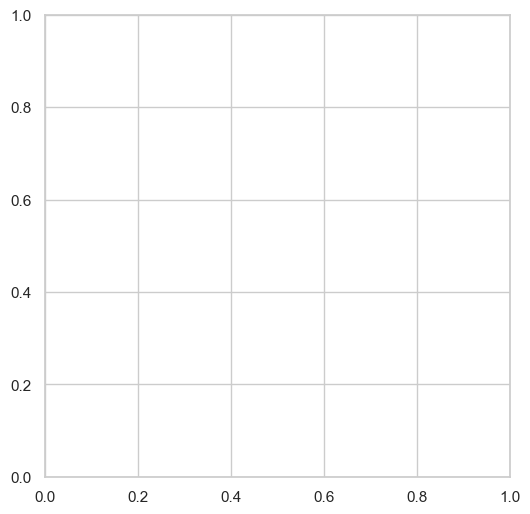

In [21]:
fig, ax = plt.subplots(figsize=(6,6))
model_rotonda = FourWayModel(params_rotonda)
anim = ap.animate(model_rotonda , fig, ax, my_plot)
from IPython.display import HTML
HTML(anim.to_jshtml())
